# **Pandas**

In [1]:
import pandas as pd

## **Series** (索引標籤＋資料)

In [2]:
a = pd.Series([12,29,72,4])
print(a)

0    12
1    29
2    72
3     4
dtype: int64


In [3]:
# 自訂索引值
fruits = ["apple", "orange", "pear"]
quantities = [15, 33, 45]
a1 = pd.Series(quantities, index=fruits)
print(a1)

apple     15
orange    33
pear      45
dtype: int64


In [4]:
print(a1.index)
print(a1.values)

Index(['apple', 'orange', 'pear'], dtype='object')
[15 33 45]


In [5]:
# 使用索引取出資料
print(a1["orange"])
print(a1[["orange", "pear"]])

33
orange    33
pear      45
dtype: int64


In [6]:
# Series 物件可以作為運算元來執行四則運算
print((a1+2)*3)

apple      51
orange    105
pear      141
dtype: int64


## **Dataframe** (索引標籤＋欄位標籤＋資料)

In [7]:
fruits = {
    "apple": [4,3,1,0],
    "banana": [0,4,6,2],
    "orange": [1,5,2,4]
}
df = pd.DataFrame(fruits)
print(df)

   apple  banana  orange
0      4       0       1
1      3       4       5
2      1       6       2
3      0       2       4


In [8]:
# 自訂索引值
city = ["台北", "新北", "台中", "高雄"]
df = pd.DataFrame(fruits, index=city)
print(df)

    apple  banana  orange
台北      4       0       1
新北      3       4       5
台中      1       6       2
高雄      0       2       4


In [9]:
# 建立 Dataframe 時，可以利用 columns 參數重新指定欄位順序
df = pd.DataFrame(fruits,
                  columns=["banana", "orange", "apple"],
                  index=city)
print(df)

    banana  orange  apple
台北       0       1      4
新北       4       5      3
台中       6       2      1
高雄       2       4      0


In [10]:
# 更改索引值標籤
city[2] = "桃園"
df.index = city
print(df)

    banana  orange  apple
台北       0       1      4
新北       4       5      3
桃園       6       2      1
高雄       2       4      0


In [11]:
# 轉置 Dataframe 物件
df.T

,台北,新北,桃園,高雄
banana,0,4,6,2
orange,1,5,2,4
apple,4,3,1,0


### 了解資料

In [12]:
print(df.head(2))
print(df.tail(2))

    banana  orange  apple
台北       0       1      4
新北       4       5      3
    banana  orange  apple
桃園       6       2      1
高雄       2       4      0


In [13]:
print(df.index)
print(df.columns)
print(df.values)

Index(['台北', '新北', '桃園', '高雄'], dtype='object')
Index(['banana', 'orange', 'apple'], dtype='object')
[[0 1 4]
 [4 5 3]
 [6 2 1]
 [2 4 0]]


In [14]:
print(len(df))
print(df.shape)

4
(4, 3)


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4 entries, 台北 to 高雄
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   banana  4 non-null      int64
 1   orange  4 non-null      int64
 2   apple   4 non-null      int64
dtypes: int64(3)
memory usage: 300.0+ bytes


### 走訪 dataframe 物件

In [16]:
for index, row in df.iterrows():
    print(index, row["apple"], row["banana"], row["orange"])

台北 4 0 1
新北 3 4 5
桃園 1 6 2
高雄 0 2 4


### 選擇、過濾與排序資料

In [17]:
products = {
    "channel": ["網路", "網路", "電視", "電視", "郵購", "郵購"],
    "company": ["EHS", "Momo", "EHS", "Viva", "Momo", "EHS"],
    "sales": [11.22, 23.50, 12.99, 15.95, 25.75, 11.55]
}
ordinals = ["A", "B", "C", "D", "E", "F"]
df1 = pd.DataFrame(products, index=ordinals)
df1

,channel,company,sales
A,網路,EHS,11.22
B,網路,Momo,23.50
C,電視,EHS,12.99
D,電視,Viva,15.95
E,郵購,Momo,25.75
F,郵購,EHS,11.55


#### 使用「欄位標籤」選取

In [18]:
df1["sales"].head(3)

A    11.22
B    23.50
C    12.99
Name: sales, dtype: float64

In [19]:
df1[["company", "sales"]].head(3)

,company,sales
A,EHS,11.22
B,Momo,23.50
C,EHS,12.99


#### 使用「索引標籤」選取

In [20]:
df1[0:2]  # 不包含終止值

,channel,company,sales
A,網路,EHS,11.22
B,網路,Momo,23.50


In [21]:
df1["C":"E"]  # 包含終止值

,channel,company,sales
C,電視,EHS,12.99
D,電視,Viva,15.95
E,郵購,Momo,25.75


#### 使用 loc / iloc 選取資料
* df.loc[索引標籤, 欄位標籤]
* df.iloc[列索引位置, 欄索引位置] --> 使用從 0 開始的索引位置值來選取資料

In [22]:
df1.loc["B"]

channel      網路
company    Momo
sales      23.5
Name: B, dtype: object

In [23]:
df1.loc[:, ["channel", "sales"]]

,channel,sales
A,網路,11.22
B,網路,23.50
C,電視,12.99
D,電視,15.95
E,郵購,25.75
F,郵購,11.55


In [24]:
df1.iloc[3]

channel       電視
company     Viva
sales      15.95
Name: D, dtype: object

In [25]:
df1.iloc[1:3, 0:2]

,channel,company
B,網路,Momo
C,電視,EHS


#### 過濾資料

In [26]:
df1[df1.sales >15]

,channel,company,sales
B,網路,Momo,23.50
D,電視,Viva,15.95
E,郵購,Momo,25.75


In [27]:
df1[(df1.sales >15) & (df1.sales<25)]

,channel,company,sales
B,網路,Momo,23.50
D,電視,Viva,15.95


#### 排序資料

In [28]:
df1.sort_values("sales", ascending=False)

,channel,company,sales
E,郵購,Momo,25.75
B,網路,Momo,23.50
D,電視,Viva,15.95
C,電視,EHS,12.99
F,郵購,EHS,11.55
A,網路,EHS,11.22


##### set_index() 利用每一欄當作索引值
##### sort_index() 利用索引值排序
* axis=0 → 對 rows 排序（也就是改變上下順序）
* axis=1 → 對 columns 排序

In [29]:
df1.set_index("sales", inplace=True)  # inplace=True 使得這一操作直接應用於原 DataFrame，而不返回新的 DataFrame
df1.sort_index(axis = 0, ascending=False)

,channel,company
sales,,
25.75,郵購,Momo
23.50,網路,Momo
15.95,電視,Viva
12.99,電視,EHS
11.55,郵購,EHS
11.22,網路,EHS


### 更新資料

In [31]:
products = {
    "channel": ["網路", "網路", "電視", "電視", "郵購", "郵購"],
    "company": ["EHS", "Momo", "EHS", "Viva", "Momo", "EHS"],
    "sales": [11.22, 23.50, 12.99, 15.95, 25.75, 11.55]
}
ordinals = ["A", "B", "C", "D", "E", "F"]
df2 = pd.DataFrame(products, index=ordinals)
df2

,channel,company,sales
A,網路,EHS,11.22
B,網路,Momo,23.50
C,電視,EHS,12.99
D,電視,Viva,15.95
E,郵購,Momo,25.75
F,郵購,EHS,11.55


In [33]:
df2.loc["A", "sales"] = 9.6
df2

,channel,company,sales
A,網路,EHS,9.60
B,網路,Momo,23.50
C,電視,EHS,12.99
D,電視,Viva,15.95
E,郵購,Momo,25.75
F,郵購,EHS,11.55


In [35]:
df2.iloc[1, 2] = 22.01
df2

,channel,company,sales
A,網路,EHS,9.60
B,網路,Momo,22.01
C,電視,EHS,12.99
D,電視,Viva,15.95
E,郵購,Momo,25.75
F,郵購,EHS,11.55


In [36]:
a = ["郵購", "Viva", 18.9]
df2.loc["C"] = a
df2

,channel,company,sales
A,網路,EHS,9.60
B,網路,Momo,22.01
C,郵購,Viva,18.90
D,電視,Viva,15.95
E,郵購,Momo,25.75
F,郵購,EHS,11.55


In [37]:
# 更新整個欄位
b = [10, 20, 30, 40, 50 ,60]
df2.loc[:, "sales"] = b
df2

,channel,company,sales
A,網路,EHS,10.0
B,網路,Momo,20.0
C,郵購,Viva,30.0
D,電視,Viva,40.0
E,郵購,Momo,50.0
F,郵購,EHS,60.0


### 刪除資料

In [38]:
df2.loc["A", "sales"] = None
df2

,channel,company,sales
A,網路,EHS,NaN
B,網路,Momo,20.0
C,郵購,Viva,30.0
D,電視,Viva,40.0
E,郵購,Momo,50.0
F,郵購,EHS,60.0


In [39]:
df2.iloc[1,2]=None
df2

,channel,company,sales
A,網路,EHS,NaN
B,網路,Momo,NaN
C,郵購,Viva,30.0
D,電視,Viva,40.0
E,郵購,Momo,50.0
F,郵購,EHS,60.0


#### drop() 可以直接刪除整個 row or column

In [40]:
df_drop1 = df2.drop(["B", "D"])
df_drop1

,channel,company,sales
A,網路,EHS,NaN
C,郵購,Viva,30.0
E,郵購,Momo,50.0
F,郵購,EHS,60.0


In [42]:
# 刪除整個欄位
df_drop2 = df2.drop(["sales"], axis =1)
df_drop2

,channel,company
A,網路,EHS
B,網路,Momo
C,郵購,Viva
D,電視,Viva
E,郵購,Momo
F,郵購,EHS


### 新增資料

In [44]:
# 新增 row
df2.loc["H"] = ["網路", "Viva", 16.5]
df2.tail(3)

,channel,company,sales
E,郵購,Momo,50.0
F,郵購,EHS,60.0
H,網路,Viva,16.5


In [45]:
 # 新增欄位
from numpy.random import randint

df2.loc[:, "items"] = randint(100, 200, size = len(df2))
df2

,channel,company,sales,items
A,網路,EHS,NaN,199
B,網路,Momo,NaN,186
C,郵購,Viva,30.0,159
D,電視,Viva,40.0,161
E,郵購,Momo,50.0,149
F,郵購,EHS,60.0,127
H,網路,Viva,16.5,160


In [46]:
df2.loc[:, "quantity"] = randint(5000, 10000, size=len(df2))
df2

,channel,company,sales,items,quantity
A,網路,EHS,NaN,199,7407
B,網路,Momo,NaN,186,8435
C,郵購,Viva,30.0,159,5302
D,電視,Viva,40.0,161,8954
E,郵購,Momo,50.0,149,8232
F,郵購,EHS,60.0,127,6049
H,網路,Viva,16.5,160,7813


### 群組、樞紐分析 與 統計函數

#### 群組 Grouping
- 先將資料依條件分類成群組後，再套用相關方法在各群組來取得統計資料

In [50]:
data = {
    "Name": ["ClientA", "ClientB", "ClientA", "ClientB", "ClientA", "ClientB", "ClientA", "ClientA"],
    "No.": ["order1", "order1", "order2", "order3", "order2", "order2", "order1", "order3"],
    "Counts": [4, 4, 1, 2, 3, 4, 2, 1],
    "Price": [495, 496, 360, 451, 221, 321, 466, 260]
}
df3 = pd.DataFrame(data)
df3

,Name,No.,Counts,Price
0,ClientA,order1,4,495
1,ClientB,order1,4,496
2,ClientA,order2,1,360
3,ClientB,order3,2,451
4,ClientA,order2,3,221
5,ClientB,order2,4,321
6,ClientA,order1,2,466
7,ClientA,order3,1,260


In [52]:
df3.groupby("Name").sum()

,No.,Counts,Price
Name,,,
ClientA,order1order2order2order1order3,11,1802
ClientB,order1order3order2,10,1268


#### 樞紐分析表: pivot_table()

In [53]:
df2

,channel,company,sales,items,quantity
A,網路,EHS,NaN,199,7407
B,網路,Momo,NaN,186,8435
C,郵購,Viva,30.0,159,5302
D,電視,Viva,40.0,161,8954
E,郵購,Momo,50.0,149,8232
F,郵購,EHS,60.0,127,6049
H,網路,Viva,16.5,160,7813


In [55]:
score = [4, 3, 5, 7, 5, 8, 6]
df2["score"] = score
df2

,channel,company,sales,items,quantity,score
A,網路,EHS,NaN,199,7407,4
B,網路,Momo,NaN,186,8435,3
C,郵購,Viva,30.0,159,5302,5
D,電視,Viva,40.0,161,8954,7
E,郵購,Momo,50.0,149,8232,5
F,郵購,EHS,60.0,127,6049,8
H,網路,Viva,16.5,160,7813,6


In [57]:
pivot_tb = df2.pivot_table(
    index = "channel",
    columns = "company",
    values = "sales"
)
pivot_tb

company,EHS,Momo,Viva
channel,,,
網路,NaN,NaN,16.5
郵購,60.0,50.0,30.0
電視,NaN,NaN,40.0


#### 統計方法

In [58]:
df2.describe()

,sales,items,quantity,score
count,5.00000,7.000000,7.000000,7.000000
mean,39.30000,163.000000,7456.000000,5.428571
std,16.95435,23.614967,1326.262669,1.718249
min,16.50000,127.000000,5302.000000,3.000000
25%,30.00000,154.000000,6728.000000,4.500000
50%,40.00000,160.000000,7813.000000,5.000000
75%,50.00000,173.500000,8333.500000,6.500000
max,60.00000,199.000000,8954.000000,8.000000


### 資料視覺化
* plot(kind="line"): 繪製折線圖
* plot(kind="bar"): 繪製長條圖

In [68]:
import numpy as np

# 建立一筆隨機資料 np.random.randn(100,4)，x為日期，columns 設定為 A,B,C,D
df4 = pd.DataFrame(np.random.randn(100,4),
                   index=pd.date_range("01/01/2026", periods=100),
                   columns=list("ABCD")
                  )
df4

,A,B,C,D
2026-01-01,-0.333677,0.456222,-2.044588,-0.730010
2026-01-02,-0.454856,-0.012604,-0.406236,-0.806561
2026-01-03,-0.279888,-1.308932,-1.645507,0.379535
2026-01-04,0.871460,-2.313842,0.526589,-0.506275
2026-01-05,-1.521563,-0.399040,0.191113,0.864869
...,...,...,...,...
2026-04-06,1.131229,1.306993,0.198627,0.063834
2026-04-07,-0.655108,1.998644,0.355586,-0.246862
2026-04-08,1.020325,0.764396,0.095598,-0.657194
2026-04-09,0.138051,0.882467,1.365349,-0.134746


In [69]:
df4 = df4.cumsum() # 累計加總
df4

,A,B,C,D
2026-01-01,-0.333677,0.456222,-2.044588,-0.730010
2026-01-02,-0.788533,0.443619,-2.450824,-1.536572
2026-01-03,-1.068421,-0.865314,-4.096331,-1.157037
2026-01-04,-0.196961,-3.179155,-3.569742,-1.663311
2026-01-05,-1.718524,-3.578196,-3.378629,-0.798442
...,...,...,...,...
2026-04-06,8.452392,-20.803416,11.172183,-0.873846
2026-04-07,7.797285,-18.804772,11.527769,-1.120708
2026-04-08,8.817610,-18.040376,11.623367,-1.777902
2026-04-09,8.955660,-17.157909,12.988716,-1.912648


<Axes: >

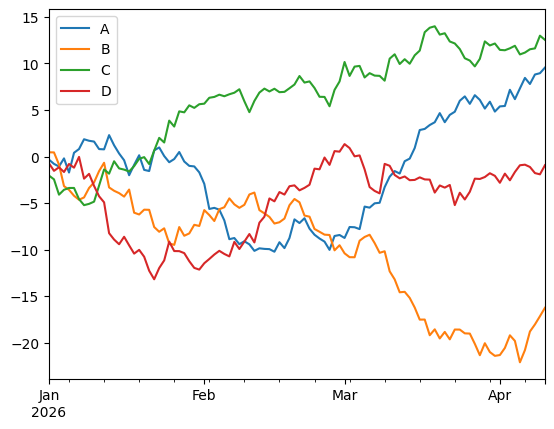

In [70]:
df4.plot()